# Model Training, Tuning & Over-fitting Control

*Companion notebook — the scripts in `src/` are the source of truth; this notebook loads and displays their outputs.*

In [1]:
import os, sys, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..')); os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from config import *


## 1. Walk-forward hyper-parameter search
`python src/training/tune_models.py` — expanding-window folds on train+val only. Best parameters per asset/model:

In [2]:
import json; print(json.dumps(json.load(open(BEST_PARAMS_PATH)), indent=1))

{
 "Bitcoin": {
  "Ridge": {
   "alpha": 100.0
  },
  "RandomForest": {
   "n_estimators": 300,
   "max_depth": 3,
   "min_samples_leaf": 30
  },
  "LightGBM": {
   "n_estimators": 400,
   "learning_rate": 0.01,
   "num_leaves": 4,
   "min_child_samples": 50,
   "subsample": 0.8,
   "colsample_bytree": 0.8,
   "reg_lambda": 5.0
  },
  "CatBoost": {
   "iterations": 500,
   "learning_rate": 0.01,
   "depth": 3,
   "l2_leaf_reg": 3.0
  },
  "GRU": {
   "units": 32,
   "dropout": 0.2,
   "learning_rate": 0.001,
   "batch_size": 32,
   "epochs": 60,
   "patience": 8
  },
  "LSTM": {
   "units": 32,
   "dropout": 0.2,
   "learning_rate": 0.001,
   "batch_size": 32,
   "epochs": 60,
   "patience": 8
  }
 },
 "Gold": {
  "Ridge": {
   "alpha": 100.0
  },
  "RandomForest": {
   "n_estimators": 300,
   "max_depth": 3,
   "min_samples_leaf": 10
  },
  "LightGBM": {
   "n_estimators": 400,
   "learning_rate": 0.03,
   "num_leaves": 4,
   "min_child_samples": 20,
   "subsample": 0.8,
   "colsample

In [3]:
pd.read_csv(os.path.join(TUNING_DIR, 'tuning_summary.csv')).round(5)

,asset,model,RMSE_ret_mean,RMSE_ret_std,MAE_ret_mean,MAE_ret_std,R2_ret_mean,R2_ret_std,DirAcc_pct_mean,DirAcc_pct_std,RMSE_usd_mean,RMSE_usd_std,best_params
0,Bitcoin,Ridge,0.02525,0.00265,0.01807,0.00224,-0.02221,0.01998,49.85714,1.63507,2089.05816,196.26314,"{""alpha"": 100.0}"
1,Bitcoin,RandomForest,0.02555,0.00266,0.01822,0.00215,-0.04698,0.03185,47.71429,1.69031,2116.97574,212.29837,"{""n_estimators"": 300, ""max_depth"": 3, ""min_sam..."
2,Bitcoin,LightGBM,0.02521,0.00262,0.01802,0.00224,-0.01938,0.01733,49.85714,1.63507,2085.72352,194.31676,"{""n_estimators"": 400, ""learning_rate"": 0.01, ""..."
3,Bitcoin,CatBoost,0.02521,0.00260,0.01802,0.00223,-0.01897,0.01685,49.85714,1.63507,2084.70375,196.30135,"{""iterations"": 500, ""learning_rate"": 0.01, ""de..."
4,Bitcoin,GRU,0.02664,0.00310,0.01940,0.00252,-0.13546,0.04873,50.57143,2.19461,2180.05308,198.07879,"{""units"": 32, ""dropout"": 0.2, ""learning_rate"":..."
5,Bitcoin,LSTM,0.02627,0.00363,0.01922,0.00309,-0.10292,0.10641,47.71429,2.69542,2156.47938,132.87298,"{""units"": 32, ""dropout"": 0.2, ""learning_rate"":..."
6,Gold,Ridge,0.01316,0.00402,0.00944,0.00214,0.00115,0.00287,57.11207,1.86643,46.23467,27.05839,"{""alpha"": 100.0}"
7,Gold,RandomForest,0.01316,0.00411,0.00943,0.00218,0.00326,0.01705,56.25000,2.94715,46.31243,27.30230,"{""n_estimators"": 300, ""max_depth"": 3, ""min_sam..."
8,Gold,LightGBM,0.01318,0.00406,0.00936,0.00209,-0.00092,0.00726,58.83621,2.68317,46.36982,27.27498,"{""n_estimators"": 400, ""learning_rate"": 0.03, ""..."
9,Gold,CatBoost,0.01312,0.00406,0.00931,0.00213,0.00902,0.01772,58.83621,4.77554,46.18204,27.16940,"{""iterations"": 500, ""learning_rate"": 0.01, ""de..."


## 2. Train vs validation performance (phase A of `train_models.py`)

In [4]:
tv = pd.read_csv(os.path.join(RESULTS_DIR, 'train_val_metrics.csv'))
tv.pivot_table(index=['asset','model'], columns='split', values='RMSE_ret').round(5)

split                   train      val
asset   model                         
Bitcoin CatBoost      0.02526  0.02643
        GRU           0.02565  0.02589
        LSTM          0.02614  0.02571
        LightGBM      0.02527  0.02644
        RandomForest  0.02417  0.02724
        Ridge         0.02520  0.02654
Gold    CatBoost      0.00996  0.02015
        GRU           0.01028  0.01966
        LSTM          0.01058  0.02031
        LightGBM      0.01030  0.02021
        RandomForest  0.00952  0.02028
        Ridge         0.01028  0.02015
Silver  CatBoost      0.01852  0.05526
        GRU           0.01931  0.05621
        LSTM          0.01914  0.05732
        LightGBM      0.01795  0.05522
        RandomForest  0.01702  0.05543
        Ridge         0.01840  0.05523

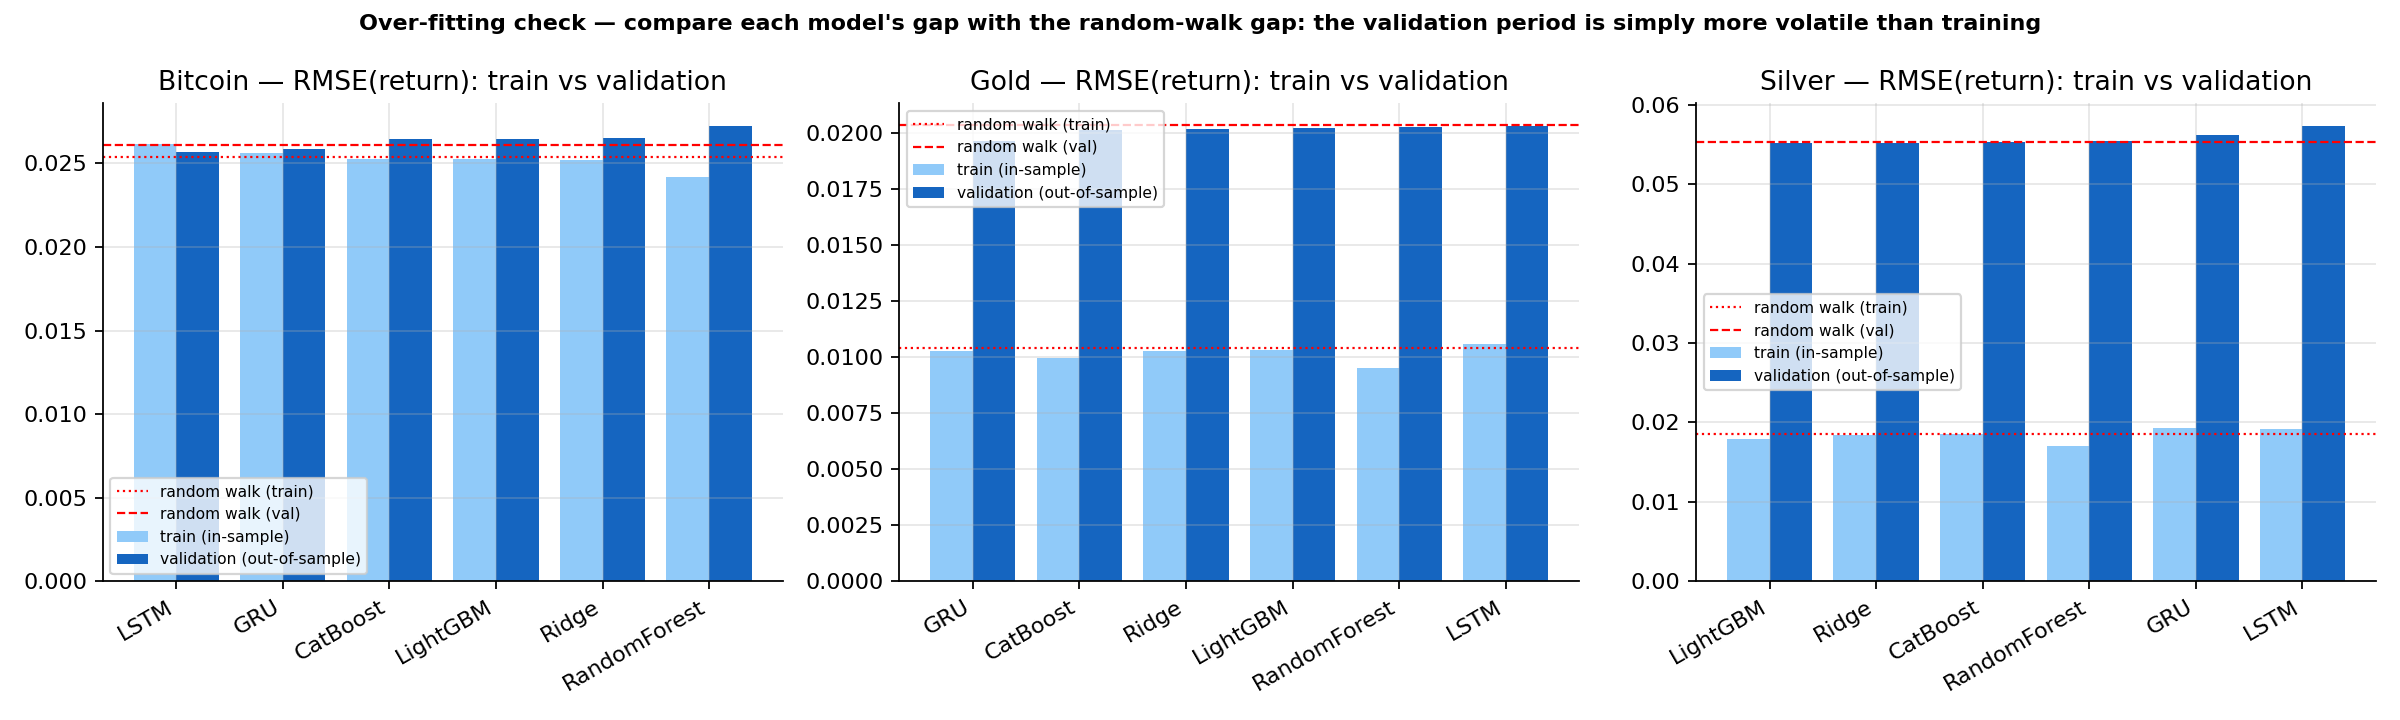

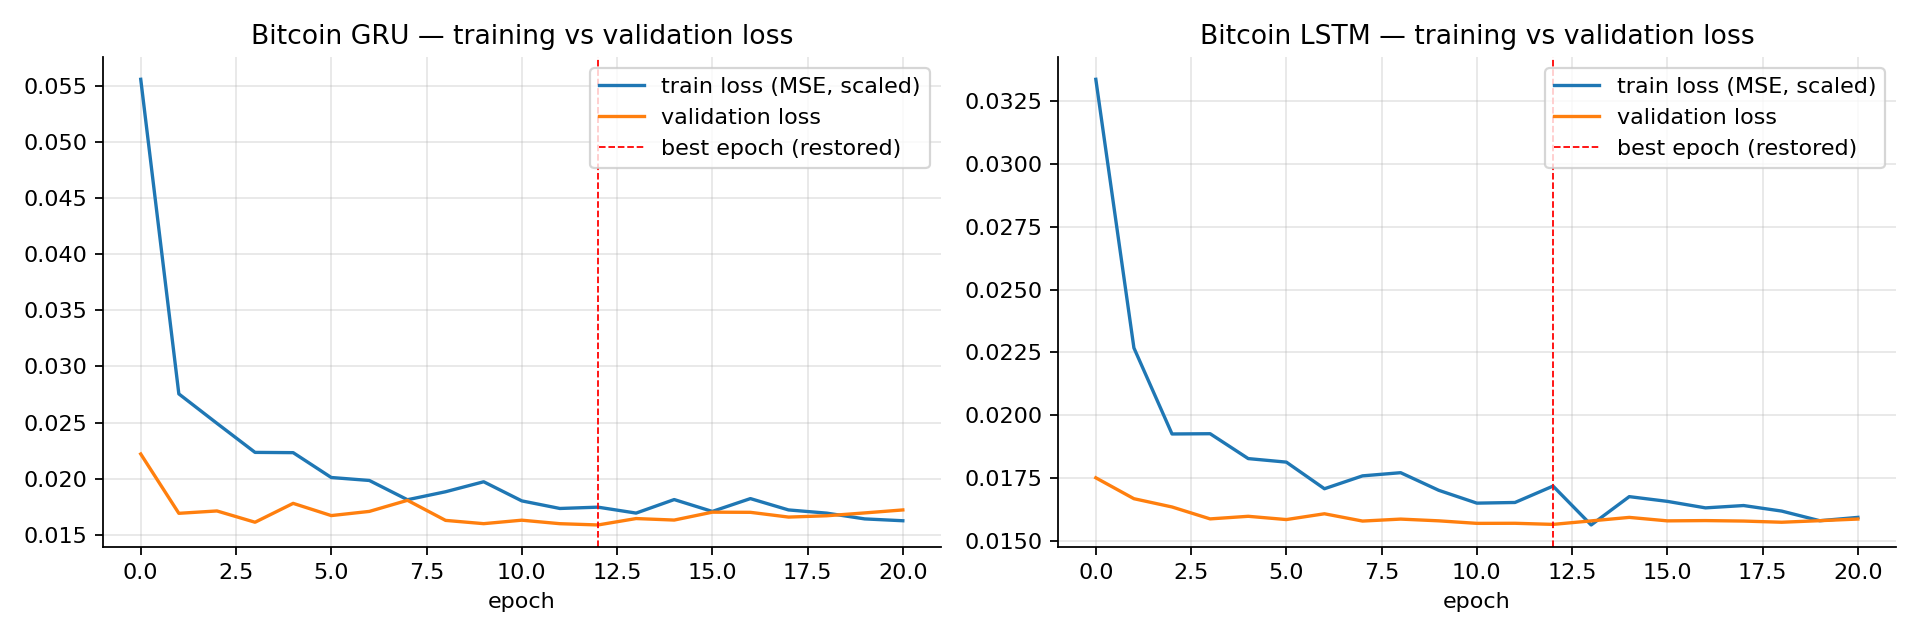

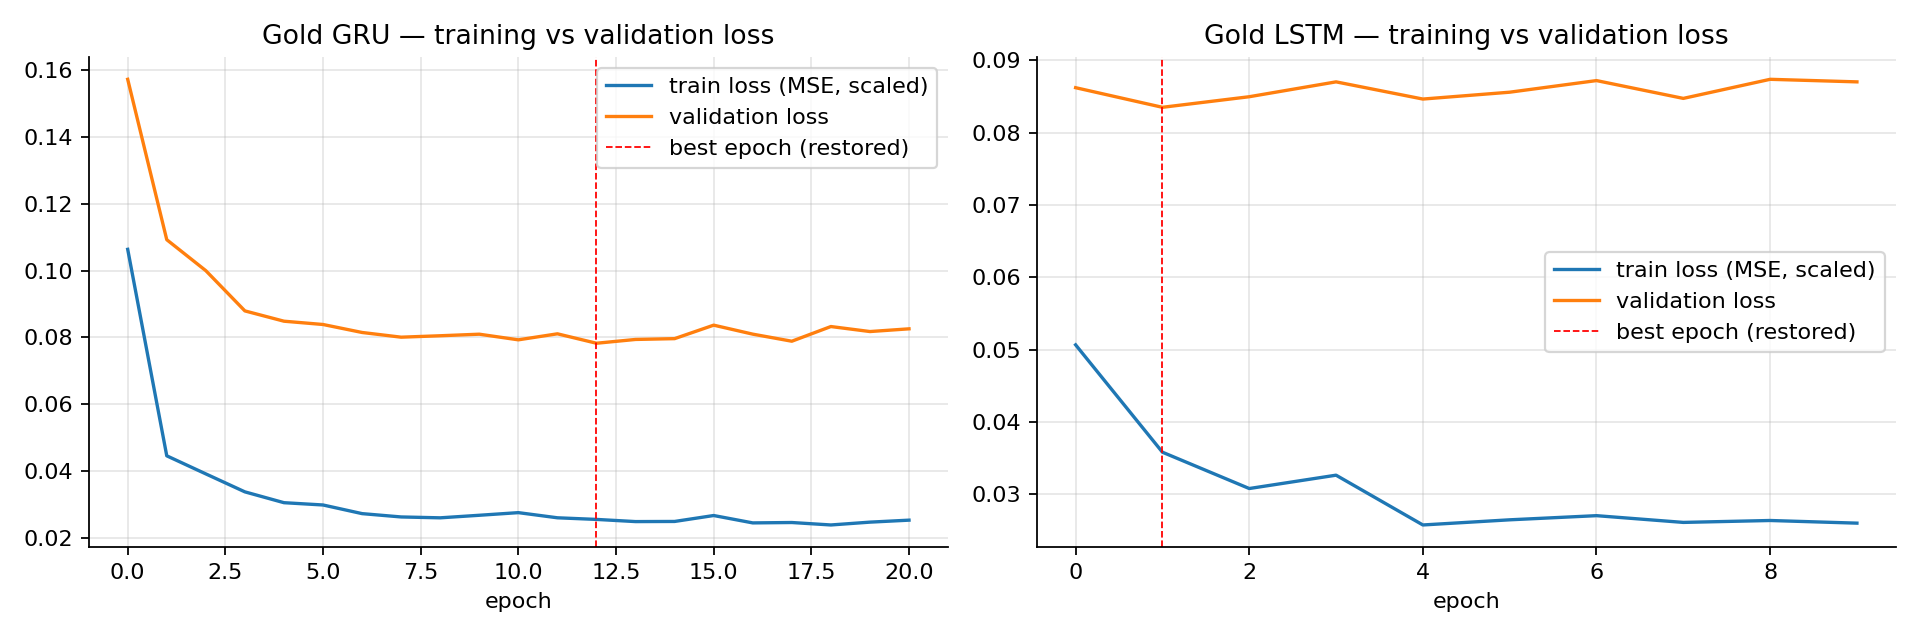

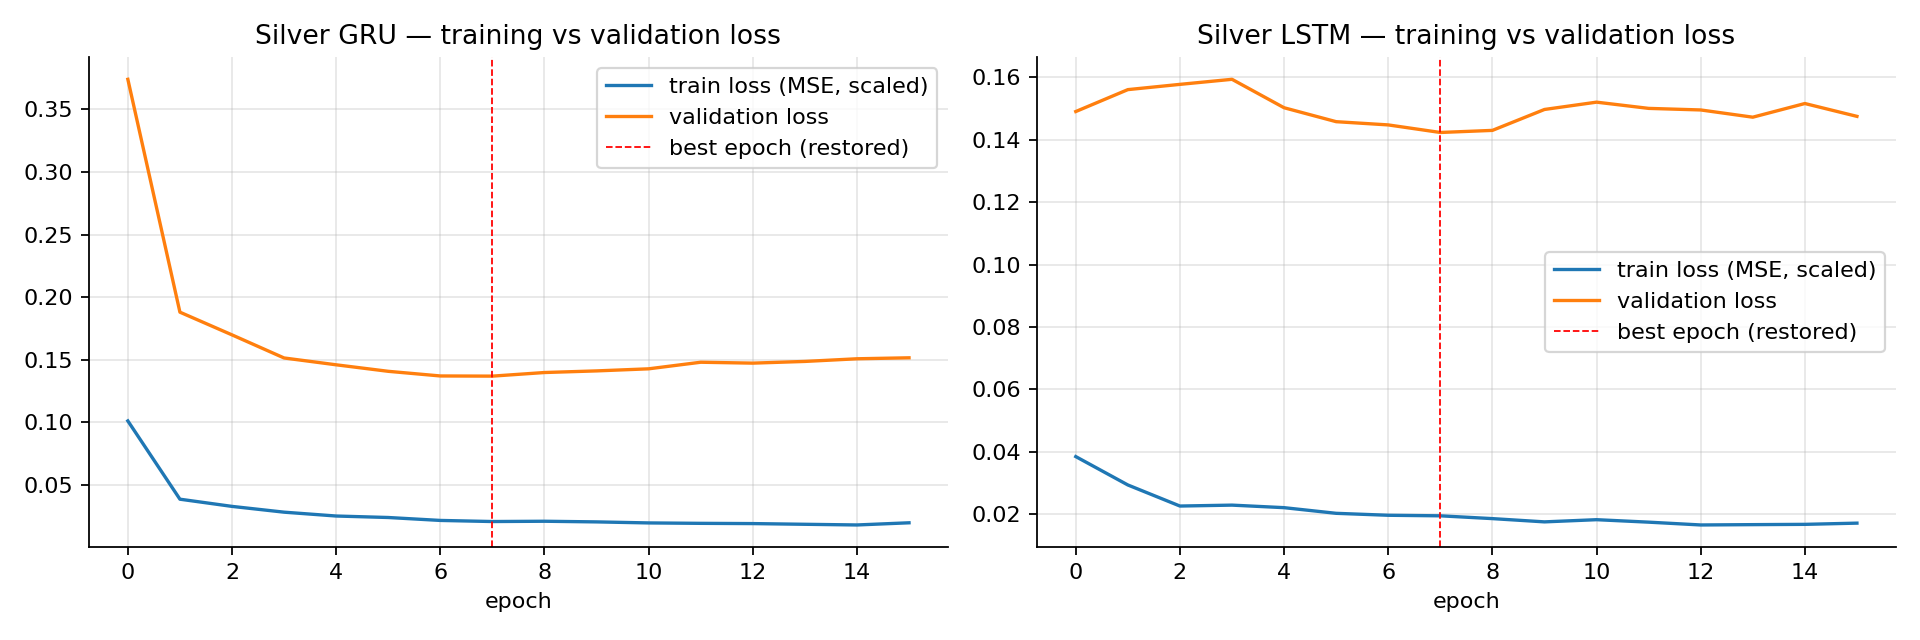

In [5]:
display(Image(os.path.join(FIGURES_DIR, 'overfitting_gap.png')))
for a in ASSETS:
    p = os.path.join(FIGURES_DIR, f'{get_prefix(a)}_loss_curves.png')
    if os.path.exists(p): display(Image(p))

## 3. Model architectures

In [6]:
from src.models.model_gru import build_gru_model
build_gru_model(SEQ_LEN, 24, units=32).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         5,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,113 (23.88 KB)

 Trainable params: 6,113 (23.88 KB)

 Non-trainable params: 0 (0.00 B)